In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                            VotingClassifier, StackingClassifier, BaggingClassifier)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load data
df = pd.read_csv('/content/Processed_data.csv')

# Prepare data
X = df.drop('Depression', axis=1)
y = df['Depression']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(df['Dietary Habits'].value_counts())
print(df['Sleep Duration'].value_counts())
df

Dietary Habits
0.333333    11682
1.000000    11556
0.000000     9364
0.666667       14
Name: count, dtype: int64
Sleep Duration
0.50    9491
0.25    8613
0.00    7259
0.75    7234
1.00      19
Name: count, dtype: int64


,Sleep Duration,Academic Pressure,Dietary Habits,Work/Study Hours,Financial Stress,Have you ever had suicidal thoughts ?,Depression
0,0.00,1.0,0.000000,0.250000,0.00,1,1
1,0.00,0.4,0.333333,0.250000,0.25,0,0
2,0.50,0.6,0.000000,0.750000,0.00,0,0
3,0.25,0.6,0.333333,0.333333,1.00,1,1
4,0.00,0.8,0.333333,0.083333,0.00,1,0
...,...,...,...,...,...,...,...
32611,0.25,0.2,1.000000,0.500000,0.25,1,0
32612,0.50,0.8,0.000000,0.879934,1.00,0,0
32613,0.50,0.4,0.333333,0.416667,0.50,0,0
32614,0.75,0.4,0.000000,0.803272,0.25,0,0


In [4]:
# Define base models
base_models = {
    'rf': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    'gb': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    'svm': SVC(C=1, kernel='rbf', probability=True, random_state=42),
    'lr': LogisticRegression(C=1, random_state=42),
    'xgb': xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
}

In [ ]:
# Train base models
for name, model in base_models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

Training rf...
rf Accuracy: 0.8176

Training gb...
gb Accuracy: 0.8552

Training svm...
svm Accuracy: 0.8317

Training lr...
lr Accuracy: 0.8319

Training xgb...
xgb Accuracy: 0.8499



In [ ]:
# Voting Classifier
voting_soft = VotingClassifier(
    estimators=[(name, model) for name, model in base_models.items()],
    voting='soft'
)
voting_soft.fit(X_train_scaled, y_train)
# Get predictions from voting classifier
voting_predictions = voting_soft.predict(X_test_scaled)

# Calculate and print accuracy
voting_accuracy = accuracy_score(y_test, voting_predictions)
print(f"Voting Classifier Accuracy: {voting_accuracy:.4f}")

# Print detailed classification report for voting classifier
print("\nVoting Classifier Classification Report:")
print(classification_report(y_test, voting_predictions))

In [ ]:
# Stacking Classifier
estimators = [(name, model) for name, model in base_models.items()]
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)
stack_clf.fit(X_train_scaled, y_train)
# Get predictions from stacking classifier
stacking_predictions = stack_clf.predict(X_test_scaled)

# Calculate and print accuracy
stacking_accuracy = accuracy_score(y_test, stacking_predictions)
print(f"Stacking Classifier Accuracy: {stacking_accuracy:.4f}")

# Print detailed classification report
print("\nStacking Classifier Classification Report:")
print(classification_report(y_test, stacking_predictions))

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(max_depth=20,
                                                       n_estimators=200,
                                                       random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(n_estimators=200,
                                                           random_state=42)),
                               ('svm',
                                SVC(C=1, probability=True, random_state=42)),
                               ('lr', LogisticRegression(C=1, random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsamp...
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.1, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=200, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...))],
                   final_estimator=LogisticRegression())

In [ ]:
# Bagging Classifier
bag_clf = BaggingClassifier(
    estimator=base_models['rf'],  # Updated parameter name
    n_estimators=10,
    random_state=42
)
bag_clf.fit(X_train_scaled, y_train)
# Get predictions from bagging classifier
bagging_predictions = bag_clf.predict(X_test_scaled)

# Calculate and print accuracy
bagging_accuracy = accuracy_score(y_test, bagging_predictions)
print(f"Bagging Classifier Accuracy: {bagging_accuracy:.4f}")

# Print detailed classification report
print("\nBagging Classifier Classification Report:")
print(classification_report(y_test, bagging_predictions))

Bagging Classifier Accuracy: 0.8243

Bagging Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      3337
           1       0.81      0.84      0.82      3187

    accuracy                           0.82      6524
   macro avg       0.82      0.82      0.82      6524
weighted avg       0.83      0.82      0.82      6524



In [ ]:
# Evaluate all models
results = {}

# Base models
for name, model in base_models.items():
    y_pred = model.predict(X_test_scaled)
    results[name] = accuracy_score(y_test, y_pred)

# Ensemble methods
ensemble_methods = {
    'Voting': voting_soft,
    'Stacking': stack_clf,
    'Bagging': bag_clf
}

for name, model in ensemble_methods.items():
    y_pred = model.predict(X_test_scaled)
    results[name] = accuracy_score(y_test, y_pred)

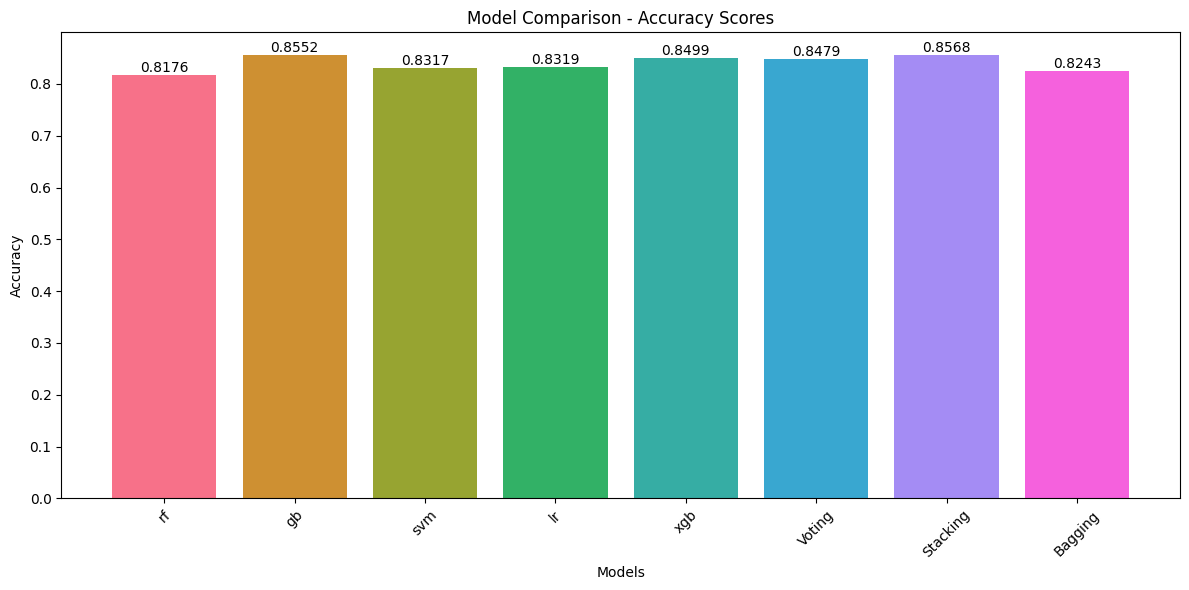

In [ ]:
# Visualize results
plt.figure(figsize=(12, 6))
colors = sns.color_palette('husl', len(results))
bars = plt.bar(results.keys(), results.values(), color=colors)
plt.title('Model Comparison - Accuracy Scores')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
# Print detailed classification reports
print("\nDetailed Classification Reports:")
for name, model in {**base_models, **ensemble_methods}.items():
    print(f"\n{name} Classification Report:")
    y_pred = model.predict(X_test_scaled)
    print(classification_report(y_test, y_pred))


Detailed Classification Reports:

rf Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      3337
           1       0.80      0.83      0.82      3187

    accuracy                           0.82      6524
   macro avg       0.82      0.82      0.82      6524
weighted avg       0.82      0.82      0.82      6524


gb Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      3337
           1       0.84      0.86      0.85      3187

    accuracy                           0.86      6524
   macro avg       0.86      0.86      0.86      6524
weighted avg       0.86      0.86      0.86      6524


svm Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      3337
           1       0.81      0.85      0.83      3187

    accuracy                           0.83      6524
   macro avg

In [5]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Initialize models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression()

# Create Voting Classifier (hard voting for classification)
voting_soft = VotingClassifier(estimators=[('rf', rf), ('lr', lr)], voting='hard')

# Train the model
voting_soft.fit(X_train, y_train)

# Predictions
y_pred = voting_soft.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score
print("Voting Classifier Accuracy:", accuracy_score(y_test, y_pred))


Voting Classifier Accuracy: 0.8366033108522379


In [6]:
import joblib
from google.colab import files
joblib.dump(voting_soft, "voting_classifier.pkl")
files.download("voting_classifier.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import pickle
import os

# Create Models directory if it doesn't exist
os.makedirs('Models', exist_ok=True)

# Save with specific protocol version (use protocol=4 for better compatibility)
try:
    # Save voting classifier
    with open('Models/voting_classifier.pkl', 'wb') as f:
        pickle.dump(voting_soft, f, protocol=4)

    # Save scaler
    with open('Models/scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f, protocol=4)

    print("Models saved successfully!")

    # Verify files
    print(f"Voting classifier size: {os.path.getsize('Models/voting_classifier.pkl')/1024:.2f} KB")
    print(f"Scaler size: {os.path.getsize('Models/scaler.pkl')/1024:.2f} KB")

except Exception as e:
    print(f"Error saving models: {str(e)}")

Models saved successfully!
Voting classifier size: 60091.90 KB
Scaler size: 0.79 KB


In [11]:
import numpy as np
import pickle
import os

# Define absolute paths to model files
MODEL_PATH = "/content/Models/voting_classifier.pkl"
SCALER_PATH = "/content/Models/scaler.pkl"

# Mapping for categorical features
sleep_duration_map = {
    "5-6 hours": 0,
    "7-8 hours": 1,
    "Less than 5 hours": 2,
    "More than 8 hours": 3,
    "Others": 4
}

dietary_habits_map = {
    "Healthy": 0,
    "Moderate": 1,
    "Others": 2,
    "Unhealthy": 3
}

suicidal_thoughts_map = {
    "No": 0,
    "Yes": 1
}

def load_models():
    """Load the trained model and scaler"""
    try:
        # Verify file existence and sizes
        if not os.path.exists(MODEL_PATH) or not os.path.exists(SCALER_PATH):
            raise FileNotFoundError("Model files not found")

        print(f"Loading models from:")
        print(f"Model: {MODEL_PATH} ({os.path.getsize(MODEL_PATH)/1024:.2f} KB)")
        print(f"Scaler: {SCALER_PATH} ({os.path.getsize(SCALER_PATH)/1024:.2f} KB)")

        with open(MODEL_PATH, "rb") as model_file:
            model = pickle.load(model_file)
        with open(SCALER_PATH, "rb") as scaler_file:
            scaler = pickle.load(scaler_file)

        print("Models loaded successfully!")
        return model, scaler
    except Exception as e:
        print(f"Error loading models: {str(e)}")
        raise

def get_user_input():
    """Get and validate user input"""
    print("\n--- Student Mental Health Prediction ---\n")

    # Your existing get_user_input code remains the same
    # ...existing code...
def get_user_input():
    print("\n--- Student Mental Health Prediction ---\n")

    while True:
        try:
            sleep_duration = input(f"Enter Sleep Duration {list(sleep_duration_map.keys())}: ").strip()
            if sleep_duration not in sleep_duration_map:
                print("Invalid input. Please choose from the given options.")
                continue
            sleep_duration = sleep_duration_map[sleep_duration]
            break
        except Exception as e:
            print(f"Error: {e}. Please try again.")

    while True:
        try:
            dietary_habits = input(f"Enter Dietary Habits {list(dietary_habits_map.keys())}: ").strip()
            if dietary_habits not in dietary_habits_map:
                print("Invalid input. Please choose from the given options.")
                continue
            dietary_habits = dietary_habits_map[dietary_habits]
            break
        except Exception as e:
            print(f"Error: {e}. Please try again.")

    while True:
        try:
            study_hours = float(input("Enter Work/Study Hours (0-24): "))
            if not 0 <= study_hours <= 24:
                print("Please enter a valid number of hours between 0 and 24.")
                continue
            break
        except ValueError:
            print("Please enter a valid number.")

    while True:
        try:
            suicidal_thoughts = input(f"Have you ever had suicidal thoughts? {list(suicidal_thoughts_map.keys())}: ").strip()
            if suicidal_thoughts not in suicidal_thoughts_map:
                print("Invalid input. Please choose Yes or No.")
                continue
            suicidal_thoughts = suicidal_thoughts_map[suicidal_thoughts]
            break
        except Exception as e:
            print(f"Error: {e}. Please try again.")

    while True:
        try:
            financial_stress = int(input("Enter Financial Stress Level (1-5): "))
            if not 1 <= financial_stress <= 5:
                print("Please enter a valid stress level between 1 and 5.")
                continue
            break
        except ValueError:
            print("Please enter a valid number.")

    while True:
        try:
            academic_pressure = int(input("Enter Academic Pressure Level (1-5): "))
            if not 1 <= academic_pressure <= 5:
                print("Please enter a valid pressure level between 1 and 5.")
                continue
            break
        except ValueError:
            print("Please enter a valid number.")

    return np.array([[sleep_duration, academic_pressure, dietary_habits, study_hours,
                      financial_stress, suicidal_thoughts]])

def main():
    try:
        # Load models first
        model, scaler = load_models()

        # Get user input
        user_data = get_user_input()

        # Scale the input
        scaled_data = scaler.transform(user_data)

        # Make prediction with confidence
        prediction = model.predict(scaled_data)
        prediction_proba = model.predict_proba(scaled_data)

        # Display result with confidence and recommendations
        if prediction[0] == 1:
            confidence = prediction_proba[0][1] * 100
            print(f"\n🔴 Depression Risk Detected ({confidence:.1f}% confidence)")
            print("\nRecommendations:")
            print("1. Consider consulting a mental health professional")
            print("2. Talk to someone you trust about your feelings")
            print("3. Maintain regular sleep schedule and healthy diet")
            if confidence > 75:
                print("\n⚠️ High confidence in depression risk detection.")
                print("Please seek professional help as soon as possible.")
        else:
            confidence = prediction_proba[0][0] * 100
            print(f"\n🟢 No Depression Risk Detected ({confidence:.1f}% confidence)")
            print("\nRecommendations:")
            print("1. Continue maintaining good mental health practices")
            print("2. Regular exercise and healthy lifestyle")
            print("3. Stay connected with friends and family")

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        return

if __name__ == "__main__":
    main()

Loading models from:
Model: /content/Models/voting_classifier.pkl (60091.90 KB)
Scaler: /content/Models/scaler.pkl (0.79 KB)
Models loaded successfully!

--- Student Mental Health Prediction ---

Enter Sleep Duration ['5-6 hours', '7-8 hours', 'Less than 5 hours', 'More than 8 hours', 'Others']: 5-6 hours
Enter Dietary Habits ['Healthy', 'Moderate', 'Others', 'Unhealthy']: Unhealthy
Enter Work/Study Hours (0-24): 8
Have you ever had suicidal thoughts? ['No', 'Yes']: Yes
Enter Financial Stress Level (1-5): 3
Enter Academic Pressure Level (1-5): 5
An error occurred: This 'VotingClassifier' has no attribute 'predict_proba'
